In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import signal
from ipywidgets import*
#import IPython.display as ipd


# Nyquist-Shannon Theorem

**According to the Nyquist-Shannon Theorem, the bandwith (the maximum frequency) of a signal must be lower than half 
of the sample rate $f_s$ of a digital system to avoid aliasing.**



----

# Aliasing

Aliasing is an (undesired) effect in digital systems, caused by frequencies that are higher than the Nyqist frequency.
Since the spectrum of a sampled signal is periodic,
it must be band-limited, in order to avoid misinterpretations,
known as aliasing. Since the spectrum is periodic with $\omega_s$,
the maximum frequency which can be represented - the Nyquist frequency -
is:
 

$$f_N = \frac{f_s}{2}$$

As soon as components of a digitally sampled signal exceed this boundary, aliases occur.


----

## The Wagon-Wheel Effect

One of the most popular examples for aliasing and *mirror frequenies* is the so-called wagon-wheel effect.
Sine even analog film works with a frame-rate, it has a Nyquist frequency.
When wheels are filmed at certain frequencies, they are too fast for the camera to capture the rotation.
When the rotation frequency hits the Nyquist frequency, the wheel stands still.
When it surpasses it, it starts turning backwards.

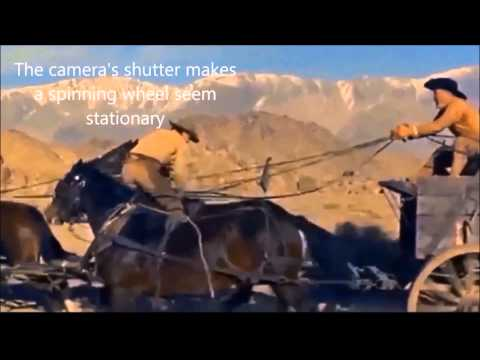

In [2]:
from IPython.display import YouTubeVideo

YouTubeVideo('6XwgbHjRo30', width=800, height=300)


In [3]:
# # 1000 Hz sampling rate
# fs = 1000

# # time vector with N samples length
# N  = 50
# t  = np.linspace(0,N/fs,N)

# f = 10

# x  = np.sin(2*np.pi*f*t)

 
# fig = plt.figure()
# #fig.suptitle("Undersampling in the Time Domain");

# ax = fig.add_subplot(1, 1, 1)
# ax.set_ylim(-1, 1)
    
# line1, = ax.plot(t, x, color = [0.5,0.5,0.5])
# plt.xlabel('t / s')
# plt.ylabel('x(t)'); 
 

----

# Aliasing Frequency for a Sinusoid


For a pure sinusoids with the frequency $f$, aliasing results in a sinusoid 
at the *mirror frequency* $f_m$:

$$f_m = \Big| f -  f_s \Big\lfloor \frac{f}{f_s} \Big\rfloor \Big|$$

With $\lfloor x \rfloor$ as round to next integer.

At a sampling rate $f_s = 1000 \ \mathrm{Hz}$ and a Nyquist frequency 
$f_N = 500 \ \mathrm{Hz}$, a sinusoid with $f = 900 \ \mathrm{Hz}$
will be interpreted as one with $f = 100 \ \mathrm{Hz}$:

In [4]:
fs = 1000
f  = 900
 
f_m =  abs(f - fs*round(f/fs)) 

#print("f_m = "+str(f_m))


<!-- The following example can be used interactively as a Jupyter notebook,
by changing the frequency of a sinusoid and listening to the aliased
output. When sweeping the range up to $2500 \ \mathrm{Hz}$, the 
resulting output will increase and decrease in frequency.
In the static version, a sinusoid of $f = 900 \ \mathrm{Hz}$
is used, resulting in an audible output at $f_m = 100 \ \mathrm{Hz}$: -->

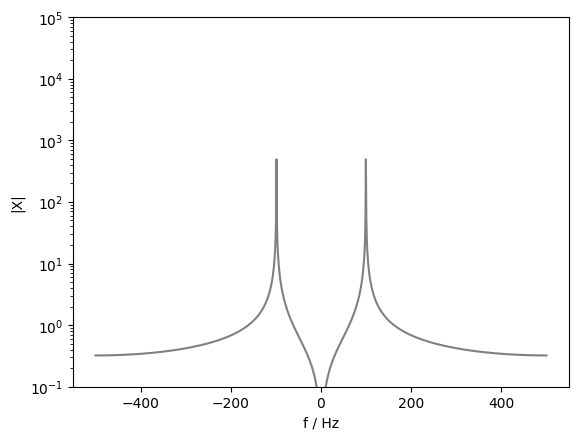

In [5]:
fs = 1000

# time vector with N samples length
N  = fs
t  = np.linspace(0,N/fs,N)

t  = np.linspace(0,1,N)

f  = 900
x  = np.sin(2*np.pi*f*t)


X = abs(np.fft.fft(x))
X = np.fft.fftshift(X)
f = np.linspace(-fs/2,fs/2,len(X))



 
# ipd.display(ipd.Audio(x, rate=fs))


fig = plt.figure()
ax  = fig.add_subplot(1, 1, 1)
ax.set_yscale('log') 
ax.set_ylim(10e-2,10e4) 

line, = ax.plot(f,X, color = [0.5,0.5,0.5]);
plt.xlabel('f / Hz')
plt.ylabel('|X|');
 
    
# # uncomment to use interactive mode:    
    
# def update(f = widgets.IntSlider(min = 0, max= 2500, step=1, value=900)):
   
    
#    x = np.sin(2*np.pi*f*t)    
    
       
#    X = abs(np.fft.fft(x))
#    X = np.fft.fftshift(X)
   
#    line.set_ydata(X)
  
#    ipd.display(ipd.Audio(x, rate=fs))
#    fig.canvas.draw_idle() 
        
# interact(update);

-----

# Aliasing for Signals with Overtones

For signals with overtones, undersampling leads to inharmonic 
alisases and happen before the fundamental itself exceeds
the Nyquist frequency.
For a harmonic signal with a fundamental frequeny $f_0$,
the alias frequencies for all $N$ harmonics can be calculated:

$$f_m = \sum\limits_{n=1}^{N} \Big| n f_0 -  f_s \Big\lfloor \frac{n f_0}{f_s} \Big\rfloor \Big|$$

For certain fundamental frequencies, all aliases will be located at actual 
multiples of the fundamental, resulting in a correct synthesis despite aliasing.
This is a square wave spectrum with $f_0 = 200 \ \mathrm{Hz}$ at $f_s = 16000 \ \mathrm{Hz}$.
All mirror frequencies fall into integer multiples of the fundamental frequency:

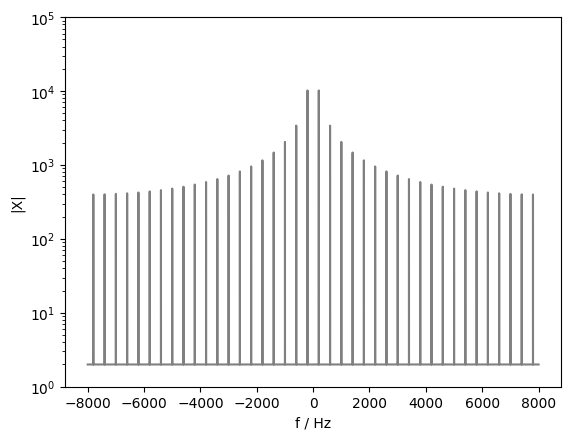

In [6]:
fs = 16000

# time vector with N samples length
N  = fs
t  = np.linspace(0,N/fs,N)

t  = np.linspace(0,1,N)

f  = 200
x  = signal.square(2*np.pi*f*t)


X = abs(np.fft.fft(x))
X = np.fft.fftshift(X)
f = np.linspace(-fs/2,fs/2,len(X))

fig = plt.figure()
ax  = fig.add_subplot(1, 1, 1)
ax.set_yscale('log') 
ax.set_ylim(10e-1,10e4) 

line, = ax.plot(f,X, color = [0.5,0.5,0.5]);
plt.xlabel('f / Hz')
plt.ylabel('|X|');
#ax.set_xlim(-1000, 1000) 
 
 
    

    
        
# uncomment to use interactive mode:    
# interact(update);

----
 
Changing the fundamental frequency of the square wave to $f_0 = 277 \ \mathrm{Hz}$,
creates alising frequencies at non-integer multiples of $f_0$.
The resulting spectrum shows the overlap of the *original* frequencies with the mirror frequencies in a pattern: 

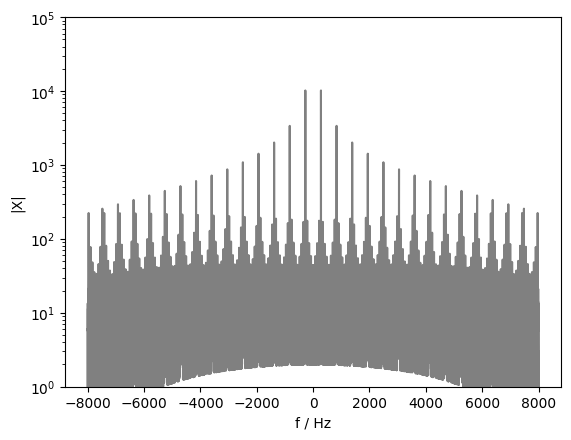

In [7]:
fs = 16000

# time vector with N samples length
N  = fs
t  = np.linspace(0,N/fs,N)

t  = np.linspace(0,1,N)

f  = 277
x  = signal.square(2*np.pi*f*t)


X = abs(np.fft.fft(x))
X = np.fft.fftshift(X)
f = np.linspace(-fs/2,fs/2,len(X))

fig = plt.figure()
ax  = fig.add_subplot(1, 1, 1)
ax.set_yscale('log') 
ax.set_ylim(10e-1,10e4) 

line, = ax.plot(f,X, color = [0.5,0.5,0.5]);
plt.xlabel('f / Hz')
plt.ylabel('|X|');
#ax.set_xlim(-1000, 1000) 
 
 
    

    
        
# uncomment to use interactive mode:    
# interact(update);

------

# Anti-Aliasing Filter

In analog-to-digital conversion, anti-aliasing filters are used to band-limit the input and discard signal components above the Nyquist frequency.

The following example shows the magnitude of the frequency response for a 5th order Butterworth 
filter with a cutoff frequency of $f_c = 0.95 \frac{f_s}{2}$:


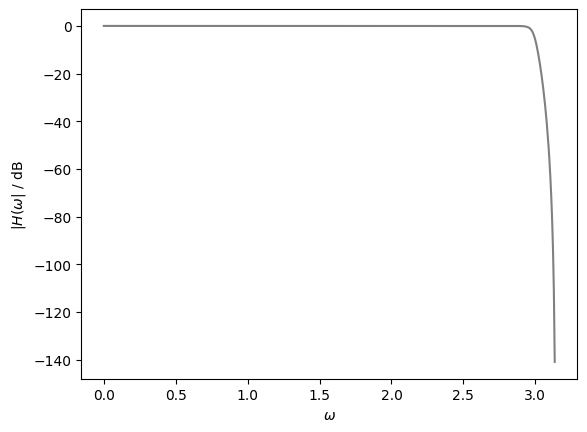

In [8]:
fs = 16000

# get coefficients for an anti aliasing filter
order = 5
b, a  = signal.butter(order, 0.95, btype='low', analog=False)

w, h = signal.freqz(b,a)
    
fig = plt.figure()


ax1 = fig.add_subplot(111)
plt.plot(w, 20 * np.log10(abs(h)), 'gray')
plt.xlabel('$\omega $')
plt.ylabel('$|H(\omega|$ / dB');


-----

# Band-Limited Synthesis

In case of digital synthesis, aliasing can occur easily. When generating a square wave signal with an infinite 
number of harmonics, aliasing happens instantaneoulsy and can not be 
removed, afterwards.

In order to avoid aliasing problems, most environments for audio signal processing and 
sound synthesis offer band-limited oscillators for specific waveforms.
Users thus do not need to worry about this issue.

<!-- The following example makes use of a Fourier series for generating
a square wave signal with $f_0 = 177 \ \mathrm{Hz}$. Partials exceeding the Nyquist frequency can thus be 
excluded from synthesis: -->



In [9]:
# fs = 16000

# def square(t,f0, fs, nPartials):

#     y = np.zeros(len(t))
    
#     for partCNT in range(nPartials):

#         if partCNT*f0 < fs/4:
#             y += (4/np.pi) * (np.sin(2*np.pi* f0 * (2* partCNT +1) *t)/(2*partCNT+1))
            
    
    
#     return y

# # time vector with N samples length
# N  = fs
# t  = np.linspace(0,N/fs,N)

# t  = np.linspace(0,1,N)

# f  = 177
# nPartials = 100
# x  = square(t, f, fs, nPartials)




# X = abs(np.fft.fft(x))
# X = np.fft.fftshift(X)
# f = np.linspace(-fs/2,fs/2,len(X))

# fig = plt.figure()

# # use for testing the square wave in time domain
# #ax1  = fig.add_subplot(2, 1, 1)
# #ax1.plot(x[0:1000]) 

# ax  = fig.add_subplot(1, 1, 1)
# ax.set_yscale('log') 
# ax.set_ylim(10e-2,10e4) 

# line, = ax.plot(f,X, color = [0.5,0.5,0.5]);
# plt.xlabel('f / Hz');
# plt.ylabel('|X|');
# #ax.set_xlim(-10000, 10000) 


    
